# 04 Whisper Transformer Emotion Head 情感分类训练

围绕毕设正式主线训练 Whisper Transformer Emotion Head 情感模型，并统一支持三种训练模式：

- `live_encoder`：直接输入音频，训练 `Whisper Encoder -> Emotion Head`
- `cached_sequence`：预缓存序列特征 `(T, D)`，用于资源受限场景下的快速结构验证
- `cached_pooled`：预缓存 pooled 特征，仅用于 `legacy_mlp` 兼容路径

模型结构、归一化、池化方式、冻结策略与 checkpoint 格式统一由 `configs/config.yaml` 中的 `shared_model` 配置控制。

本 notebook 当前默认关注两类结果：

- 跨架构对比：`CNN+BiLSTM+Attention`（早期探索） vs `Whisper+Transformer Emotion Head`（正式主线）
- 主线关键对比：`Derf` vs `DyT`，协议固定为 `live_encoder + attention + unfreeze_last_2`

`LayerNorm` 与额外冻结策略仍保留在代码和 checkpoint 兼容路径中，但不再作为默认实验工作流。


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q openai-whisper noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/Emotion-perception-driven-speech-recognition-system


In [2]:
import sys
import time
import copy
import math
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import whisper
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config, EMOTION_LABELS, LABEL2ID
from utils.losses import FocalLoss
from utils.split_utils import (
    audit_subset_groups,
    build_group_holdout_folds,
    infer_subset_from_path,
    speaker_group_split,
    validate_subset_groups,
)
from preprocessing.feature_extract import AudioAugmentation
from preprocessing.whisper_feature_cache import (
    build_sample_list,
    prepare_whisper_training_data,
    build_whisper_mel_batch,
    collate_whisper_audio_batch,
    TRAINING_MODE_LIVE_ENCODER,
    TRAINING_MODE_CACHED_SEQUENCE,
    TRAINING_MODE_CACHED_POOLED,
)
from models.whisper_emotion import (
    WhisperEmotionHead,
    build_shared_model_from_config,
    create_shared_checkpoint,
    DEFAULT_SHARED_MODEL_CONFIG,
)

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

seed = int(cfg['training'].get('seed', 42))
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


def get_training_value(key, default=None, mode=None):
    mode = mode or training_mode
    training_cfg = cfg.get('training', {})
    mode_key = f'{mode}_{key}'
    if mode_key in training_cfg:
        return training_cfg[mode_key]
    return training_cfg.get(key, default)


shared_model_cfg = cfg.get('shared_model', {})
training_mode = str(shared_model_cfg.get('training_mode', DEFAULT_SHARED_MODEL_CONFIG.get('training_mode', TRAINING_MODE_LIVE_ENCODER))).strip().lower()


def get_shared_value(key, default=None, mode=None, prefer_mode_specific=True):
    mode = mode or training_mode
    mode_key = f'{mode}_{key}'
    if not prefer_mode_specific:
        if key in shared_model_cfg:
            return shared_model_cfg[key]
        if mode_key in shared_model_cfg:
            return shared_model_cfg[mode_key]
        return default
    if mode_key in shared_model_cfg:
        return shared_model_cfg[mode_key]
    return shared_model_cfg.get(key, default)


shared_cfg = dict(DEFAULT_SHARED_MODEL_CONFIG)
shared_cfg.update(shared_model_cfg)
variant = str(get_shared_value('variant', shared_cfg.get('variant', 'transformer_head'), training_mode)).strip().lower()
shared_cfg['variant'] = variant
shared_cfg['pooling'] = str(get_shared_value('pooling', shared_cfg.get('pooling', 'attention'), training_mode)).strip().lower()
shared_cfg['norm'] = str(get_shared_value('norm', shared_cfg.get('norm', 'derf'), training_mode, prefer_mode_specific=False)).strip().lower()
shared_cfg['freeze_strategy'] = str(get_shared_value('freeze_strategy', shared_cfg.get('freeze_strategy', 'freeze_all'), training_mode)).strip().lower()
shared_cfg['head_layers'] = int(get_shared_value('head_layers', shared_cfg.get('head_layers', 2), training_mode))
shared_cfg['head_hidden_dim'] = get_shared_value('head_hidden_dim', shared_cfg.get('head_hidden_dim'), training_mode)
if shared_cfg['head_hidden_dim'] is not None:
    shared_cfg['head_hidden_dim'] = int(shared_cfg['head_hidden_dim'])
shared_cfg['num_heads'] = int(get_shared_value('num_heads', shared_cfg.get('num_heads', 8), training_mode))
shared_cfg['ff_mult'] = int(get_shared_value('ff_mult', shared_cfg.get('ff_mult', 4), training_mode))
shared_cfg['classifier_hidden'] = int(get_shared_value('classifier_hidden', shared_cfg.get('classifier_hidden', 256), training_mode))
shared_cfg['attention_pool_hidden'] = int(get_shared_value('attention_pool_hidden', shared_cfg.get('attention_pool_hidden', 256), training_mode))
shared_cfg['legacy_hidden_dims'] = list(get_shared_value('legacy_hidden_dims', shared_cfg.get('legacy_hidden_dims', (256, 64)), training_mode))
shared_cfg['dropout'] = float(get_training_value('dropout', get_shared_value('dropout', shared_cfg.get('dropout', 0.1), training_mode), training_mode))
whisper_size = cfg['model']['whisper_size']
num_classes = int(cfg['emotion']['num_classes'])

print('共享模型配置:')
print({
    'variant': variant,
    'training_mode': training_mode,
    'pooling': shared_cfg.get('pooling'),
    'norm': shared_cfg.get('norm'),
    'freeze_strategy': shared_cfg.get('freeze_strategy'),
    'head_layers': shared_cfg.get('head_layers'),
    'head_hidden_dim': shared_cfg.get('head_hidden_dim'),
    'num_heads': shared_cfg.get('num_heads'),
    'ff_mult': shared_cfg.get('ff_mult'),
    'classifier_hidden': shared_cfg.get('classifier_hidden'),
    'attention_pool_hidden': shared_cfg.get('attention_pool_hidden'),
    'dropout': shared_cfg.get('dropout'),
    'best_metric': 'val_subset_mean_uar -> val_uar -> val_loss',
})


设备: cuda
GPU: NVIDIA GeForce RTX 4090
共享模型配置:
{'variant': 'transformer_head', 'training_mode': 'live_encoder', 'pooling': 'attention', 'norm': 'derf', 'freeze_strategy': 'unfreeze_last_4', 'head_layers': 2, 'head_hidden_dim': 768, 'num_heads': 8, 'ff_mult': 4, 'classifier_hidden': 256, 'attention_pool_hidden': 256, 'dropout': 0.2, 'best_metric': 'val_subset_mean_uar -> val_uar -> val_loss'}


## 1. 准备数据集

In [3]:
feature_bs = int(cfg.get('training', {}).get('whisper_feature_batch_size', 8))
feature_workers = int(cfg.get('training', {}).get('whisper_feature_num_workers', 0))
feature_prefetch = int(cfg.get('training', {}).get('whisper_feature_prefetch_factor', 2))
cache_dtype = str(shared_cfg.get('cache_feature_dtype', 'float16'))
protocol_version = int(get_training_value('protocol_version', 2, training_mode))
default_main_subsets = ('ravdess', 'casia', 'esd', 'emodb', 'iemocap')
default_auxiliary_subsets = ('tess',)
main_subsets = tuple(str(subset).strip().lower() for subset in get_training_value('main_subsets', default_main_subsets, training_mode))
auxiliary_subsets = tuple(str(subset).strip().lower() for subset in get_training_value('auxiliary_subsets', default_auxiliary_subsets, training_mode))
seed_sweep = [int(value) for value in get_training_value('seed_sweep', [seed], training_mode)]

if not main_subsets:
    raise ValueError('main_subsets 不能为空')
if set(main_subsets) & set(auxiliary_subsets):
    raise ValueError(f'main_subsets 与 auxiliary_subsets 不能重叠: {set(main_subsets) & set(auxiliary_subsets)}')

requested_subset_set = set(main_subsets) | set(auxiliary_subsets)
subsets = tuple(subset for subset in ('ravdess', 'casia', 'tess', 'esd', 'emodb', 'iemocap') if subset in requested_subset_set)
if not subsets:
    raise ValueError('当前配置未启用任何数据子集')

default_subset_epoch_targets = {
    'casia': 900,
    'emodb': 700,
    'esd': 2000,
    'iemocap': 2200,
    'ravdess': 1200,
}
legacy_subset_epoch_targets = get_training_value('subset_epoch_caps', default_subset_epoch_targets, training_mode)
if not isinstance(legacy_subset_epoch_targets, dict):
    legacy_subset_epoch_targets = default_subset_epoch_targets
subset_epoch_targets_cfg = get_training_value('subset_epoch_targets', legacy_subset_epoch_targets, training_mode)
if not isinstance(subset_epoch_targets_cfg, dict):
    subset_epoch_targets_cfg = legacy_subset_epoch_targets
subset_epoch_targets = {
    subset: int(subset_epoch_targets_cfg.get(subset, legacy_subset_epoch_targets.get(subset, default_subset_epoch_targets.get(subset, 0))))
    for subset in main_subsets
}
subset_epoch_caps = dict(subset_epoch_targets)  # legacy alias for downstream summaries / plots
subset_sampling_mode = str(get_training_value('subset_sampling_mode', 'balanced_class_aware', training_mode)).strip().lower()
if subset_sampling_mode not in {'uniform', 'balanced_class_aware'}:
    raise ValueError(f'不支持的 subset_sampling_mode: {subset_sampling_mode}')
subset_sampling_with_replacement = bool(get_training_value('subset_sampling_with_replacement', True, training_mode))
subset_class_balance_power = float(get_training_value('subset_class_balance_power', 0.5, training_mode))
if subset_class_balance_power < 0:
    raise ValueError('subset_class_balance_power 必须 >= 0')


def resolve_subset_target(subset, raw_count):
    configured = int(subset_epoch_targets.get(subset, raw_count))
    if configured <= 0:
        return int(raw_count)
    return configured


dataset, meta = prepare_whisper_training_data(
    cfg=cfg,
    device=device,
    subsets=subsets,
    batch_size=feature_bs,
    feature_dtype=cache_dtype,
    overwrite=False,
    num_workers=feature_workers,
    prefetch_factor=feature_prefetch,
)
print(f'训练数据元信息: {meta}')

sample_list = build_sample_list(cfg['paths']['processed_data'], LABEL2ID, subsets=subsets)
if len(sample_list) != len(dataset):
    raise RuntimeError(
        f'样本列表与 dataset 长度不一致: samples={len(sample_list)} dataset={len(dataset)}'
    )

sample_paths = [wav_path for wav_path, _ in sample_list]
sample_labels = np.asarray([label for _, label in sample_list], dtype=np.int64)
sample_subsets = np.asarray([infer_subset_from_path(path) for path in sample_paths], dtype=object)
train_ratio = float(cfg['training']['train_ratio'])
val_ratio = float(cfg['training']['val_ratio'])
test_ratio = float(cfg['training']['test_ratio'])

dataset_audit = audit_subset_groups(
    sample_paths,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    subsets=subsets,
)
main_subset_audit = validate_subset_groups(
    sample_paths,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    subsets=main_subsets,
)


def compress_holdout_plan(plan):
    compact = dict(plan)
    compact['folds'] = [
        {
            key: value
            for key, value in fold.items()
            if not key.endswith('_indices')
        }
        for fold in plan.get('folds', [])
    ]
    return compact


auxiliary_eval_plan = {}
for subset in auxiliary_subsets:
    try:
        auxiliary_eval_plan[subset] = compress_holdout_plan(
            build_group_holdout_folds(sample_paths, subset)
        )
    except ValueError as exc:
        auxiliary_eval_plan[subset] = {
            'subset': subset,
            'error': str(exc),
        }

train_indices, val_indices, test_indices, split_meta = speaker_group_split(
    sample_paths,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    seed=seed,
    include_subsets=main_subsets,
)
split_meta.update({
    'protocol_version': int(protocol_version),
    'seed': int(seed),
    'seed_sweep': list(seed_sweep),
    'main_subsets': list(main_subsets),
    'auxiliary_subsets': list(auxiliary_subsets),
    'dataset_audit': dataset_audit['subset_audit'],
    'dataset_normalization_warnings': dataset_audit['normalization_warnings'],
    'auxiliary_eval_plan': auxiliary_eval_plan,
})

train_set = Subset(dataset, train_indices)
val_set = Subset(dataset, val_indices)
test_set = Subset(dataset, test_indices)
train_n = len(train_set)
val_n = len(val_set)
test_n = len(test_set)

train_sample_labels = sample_labels[train_indices]
train_sample_subsets = sample_subsets[train_indices]
raw_train_class_counts = np.bincount(train_sample_labels, minlength=num_classes).astype(np.int64)

train_relative_indices_by_subset = {}
train_relative_labels_by_subset = {}
raw_train_subset_counts = {}
for subset in main_subsets:
    relative_indices = np.asarray(
        [idx for idx, sample_subset in enumerate(train_sample_subsets) if sample_subset == subset],
        dtype=np.int64,
    )
    train_relative_indices_by_subset[subset] = relative_indices
    train_relative_labels_by_subset[subset] = train_sample_labels[relative_indices]
    raw_train_subset_counts[subset] = int(len(relative_indices))


def compute_subset_sampling_distribution(labels, num_classes, sampling_mode, balance_power):
    labels = np.asarray(labels, dtype=np.int64)
    subset_class_counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    raw_count = int(labels.size)
    if raw_count == 0:
        return np.asarray([], dtype=np.float64), subset_class_counts, np.zeros(num_classes, dtype=np.float64)

    if sampling_mode == 'balanced_class_aware':
        class_weights = np.zeros(num_classes, dtype=np.float64)
        nonzero = subset_class_counts > 0
        class_weights[nonzero] = np.power(subset_class_counts[nonzero], -float(balance_power))
        sample_weights = class_weights[labels]
    else:
        sample_weights = np.ones(raw_count, dtype=np.float64)

    sample_probs = sample_weights / sample_weights.sum()
    class_probs = np.zeros(num_classes, dtype=np.float64)
    for class_idx in range(num_classes):
        class_probs[class_idx] = float(sample_probs[labels == class_idx].sum())
    return sample_probs, subset_class_counts, class_probs


def compute_virtual_subset_class_counts(
    subset_label_map,
    subset_targets,
    subset_order,
    num_classes,
    sampling_mode,
    balance_power,
    with_replacement,
):
    class_counts = np.zeros(num_classes, dtype=np.float64)
    raw_subset_counts = {}
    effective_subset_counts = {}
    oversampled_subset_counts = {}

    for subset in subset_order:
        labels = np.asarray(subset_label_map.get(subset, np.asarray([], dtype=np.int64)), dtype=np.int64)
        raw_count = int(labels.size)
        target_count = resolve_subset_target(subset, raw_count)
        effective_count = target_count if (with_replacement or target_count <= raw_count) else raw_count
        raw_subset_counts[subset] = raw_count
        effective_subset_counts[subset] = int(effective_count)
        oversampled_subset_counts[subset] = int(max(0, effective_count - raw_count))

        if raw_count == 0 or effective_count <= 0:
            continue

        _, subset_class_counts, class_probs = compute_subset_sampling_distribution(
            labels,
            num_classes,
            sampling_mode,
            balance_power,
        )
        if sampling_mode == 'uniform' or not with_replacement:
            scaled_counts = subset_class_counts * (float(min(effective_count, raw_count)) / float(raw_count))
            if effective_count > raw_count and with_replacement:
                scaled_counts += class_probs * float(effective_count - raw_count)
            class_counts += scaled_counts
        else:
            class_counts += class_probs * float(effective_count)

    return class_counts, {
        'subset_targets': {subset: int(resolve_subset_target(subset, raw_subset_counts.get(subset, 0))) for subset in subset_order},
        'raw_subset_counts': raw_subset_counts,
        'effective_subset_counts': effective_subset_counts,
        'oversampled_subset_counts': oversampled_subset_counts,
        'effective_train_samples_per_epoch': int(sum(effective_subset_counts.values())),
        'effective_esd_samples_per_epoch': int(effective_subset_counts.get('esd', 0)),
        'sampling_mode': sampling_mode,
        'sampling_with_replacement': bool(with_replacement),
        'class_balance_power': float(balance_power),
    }


def compute_class_weights(class_counts, num_classes):
    class_counts = np.asarray(class_counts, dtype=np.float64)
    clipped = np.maximum(class_counts, 1e-6)
    weights = 1.0 / clipped
    weights = weights / weights.sum() * num_classes
    return weights.astype(np.float32)


virtual_train_class_counts, train_sampling_meta = compute_virtual_subset_class_counts(
    train_relative_labels_by_subset,
    subset_epoch_targets,
    main_subsets,
    num_classes,
    subset_sampling_mode,
    subset_class_balance_power,
    subset_sampling_with_replacement,
)
class_weights = compute_class_weights(virtual_train_class_counts, num_classes)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
virtual_train_class_counts_dict = {
    label: float(count)
    for label, count in zip(cfg['emotion']['labels'], virtual_train_class_counts)
}
class_weights_dict = {
    label: float(weight)
    for label, weight in zip(cfg['emotion']['labels'], class_weights)
}

esd_epoch_cap = int(train_sampling_meta['effective_subset_counts'].get('esd', 0))
raw_esd_train_samples = int(raw_train_subset_counts.get('esd', 0))
raw_non_esd_train_samples = int(train_n - raw_esd_train_samples)


def format_subset_counts(counts):
    entries = [f'{subset}={int(counts.get(subset, 0))}' for subset in main_subsets if int(counts.get(subset, 0)) > 0]
    return ', '.join(entries) if entries else 'none'


def sample_subset_relative_indices(relative_indices, relative_labels, target_count, sampling_mode, balance_power, rng, with_replacement):
    relative_indices = np.asarray(relative_indices, dtype=np.int64)
    relative_labels = np.asarray(relative_labels, dtype=np.int64)
    raw_count = int(len(relative_indices))
    if raw_count == 0 or target_count <= 0:
        return np.asarray([], dtype=np.int64)

    sample_probs, _, _ = compute_subset_sampling_distribution(
        relative_labels,
        num_classes,
        sampling_mode,
        balance_power,
    )

    if target_count <= raw_count:
        selected = rng.choice(relative_indices, size=target_count, replace=False, p=sample_probs)
        return np.asarray(selected, dtype=np.int64)

    selected_parts = [relative_indices.copy()]
    if with_replacement and target_count > raw_count:
        extra = rng.choice(relative_indices, size=target_count - raw_count, replace=True, p=sample_probs)
        selected_parts.append(np.asarray(extra, dtype=np.int64))

    return np.concatenate(selected_parts).astype(np.int64, copy=False)


def build_epoch_train_relative_indices(
    epoch,
    seed,
    subset_relative_indices,
    subset_relative_labels,
    subset_targets,
    subset_order,
    sampling_mode,
    balance_power,
    with_replacement,
):
    selected_parts = []
    effective_subset_counts = {}
    oversampled_subset_counts = {}

    for subset_offset, subset in enumerate(subset_order):
        relative_indices = subset_relative_indices.get(subset, np.asarray([], dtype=np.int64))
        relative_labels = subset_relative_labels.get(subset, np.asarray([], dtype=np.int64))
        raw_count = int(len(relative_indices))
        target_count = resolve_subset_target(subset, raw_count)

        subset_rng = np.random.default_rng(int(seed) * 1009 + int(epoch) * 97 + subset_offset * 17)
        selected = sample_subset_relative_indices(
            relative_indices,
            relative_labels,
            target_count,
            sampling_mode,
            balance_power,
            subset_rng,
            with_replacement,
        )
        effective_subset_counts[subset] = int(len(selected))
        oversampled_subset_counts[subset] = int(max(0, len(selected) - raw_count))
        if len(selected) > 0:
            selected_parts.append(selected)

    if selected_parts:
        combined = np.concatenate(selected_parts).astype(np.int64, copy=False)
        shuffle_rng = np.random.default_rng(int(seed) * 2003 + int(epoch))
        shuffled = shuffle_rng.permutation(combined)
    else:
        shuffled = np.array([], dtype=np.int64)

    return shuffled.tolist(), {
        'effective_subset_counts': effective_subset_counts,
        'oversampled_subset_counts': oversampled_subset_counts,
        'effective_train_samples': int(len(shuffled)),
        'effective_esd_samples': int(effective_subset_counts.get('esd', 0)),
    }


def build_epoch_train_loader(epoch):
    effective_indices, epoch_sampling = build_epoch_train_relative_indices(
        epoch,
        seed,
        train_relative_indices_by_subset,
        train_relative_labels_by_subset,
        subset_epoch_targets,
        main_subsets,
        subset_sampling_mode,
        subset_class_balance_power,
        subset_sampling_with_replacement,
    )
    effective_train_set = Subset(train_set, effective_indices)
    loader = DataLoader(effective_train_set, shuffle=False, **train_loader_kwargs)
    return loader, epoch_sampling


base_batch_size = int(cfg['training']['batch_size'])
default_live_train_batch_size = min(base_batch_size, 16 if device.type == 'cuda' else 8)
default_live_eval_batch_size = min(base_batch_size, max(default_live_train_batch_size, 16 if device.type == 'cuda' else 8))
default_cached_sequence_batch_size = min(base_batch_size, 32)
default_cached_pooled_batch_size = base_batch_size

if training_mode == TRAINING_MODE_LIVE_ENCODER:
    train_batch_size = int(cfg['training'].get('live_encoder_batch_size', default_live_train_batch_size))
    eval_batch_size = int(cfg['training'].get('live_encoder_eval_batch_size', default_live_eval_batch_size))
    train_num_workers = int(cfg['training'].get('live_encoder_num_workers', 0))
    eval_num_workers = int(cfg['training'].get('live_encoder_eval_num_workers', train_num_workers))
    train_prefetch_factor = int(cfg['training'].get('live_encoder_prefetch_factor', 2))
    eval_prefetch_factor = int(cfg['training'].get('live_encoder_eval_prefetch_factor', train_prefetch_factor))
    train_persistent_workers = bool(cfg['training'].get('live_encoder_persistent_workers', train_num_workers > 0))
    eval_persistent_workers = bool(cfg['training'].get('live_encoder_eval_persistent_workers', eval_num_workers > 0))
elif training_mode == TRAINING_MODE_CACHED_SEQUENCE:
    train_batch_size = int(cfg['training'].get('cached_sequence_batch_size', default_cached_sequence_batch_size))
    eval_batch_size = int(cfg['training'].get('cached_sequence_eval_batch_size', train_batch_size))
    train_num_workers = int(cfg['training'].get('cached_sequence_num_workers', 0))
    eval_num_workers = int(cfg['training'].get('cached_sequence_eval_num_workers', train_num_workers))
    train_prefetch_factor = int(cfg['training'].get('cached_sequence_prefetch_factor', 2))
    eval_prefetch_factor = int(cfg['training'].get('cached_sequence_eval_prefetch_factor', train_prefetch_factor))
    train_persistent_workers = bool(cfg['training'].get('cached_sequence_persistent_workers', train_num_workers > 0))
    eval_persistent_workers = bool(cfg['training'].get('cached_sequence_eval_persistent_workers', eval_num_workers > 0))
else:
    train_batch_size = int(cfg['training'].get('cached_pooled_batch_size', default_cached_pooled_batch_size))
    eval_batch_size = int(cfg['training'].get('cached_pooled_eval_batch_size', train_batch_size))
    train_num_workers = int(cfg['training'].get('cached_pooled_num_workers', 0))
    eval_num_workers = int(cfg['training'].get('cached_pooled_eval_num_workers', train_num_workers))
    train_prefetch_factor = int(cfg['training'].get('cached_pooled_prefetch_factor', 2))
    eval_prefetch_factor = int(cfg['training'].get('cached_pooled_eval_prefetch_factor', train_prefetch_factor))
    train_persistent_workers = bool(cfg['training'].get('cached_pooled_persistent_workers', train_num_workers > 0))
    eval_persistent_workers = bool(cfg['training'].get('cached_pooled_eval_persistent_workers', eval_num_workers > 0))

pin_memory = device.type == 'cuda'

train_loader_kwargs = {
    'batch_size': train_batch_size,
    'pin_memory': pin_memory,
    'num_workers': train_num_workers,
}
eval_loader_kwargs = {
    'batch_size': eval_batch_size,
    'pin_memory': pin_memory,
    'num_workers': eval_num_workers,
}
if train_num_workers > 0:
    train_loader_kwargs['persistent_workers'] = train_persistent_workers
    train_loader_kwargs['prefetch_factor'] = train_prefetch_factor
if eval_num_workers > 0:
    eval_loader_kwargs['persistent_workers'] = eval_persistent_workers
    eval_loader_kwargs['prefetch_factor'] = eval_prefetch_factor
if training_mode == TRAINING_MODE_LIVE_ENCODER:
    train_loader_kwargs['collate_fn'] = collate_whisper_audio_batch
    eval_loader_kwargs['collate_fn'] = collate_whisper_audio_batch


def build_subset_eval_loaders(global_indices, subset_order):
    loaders = {}
    subset_counts = {}
    for subset in subset_order:
        subset_indices = [int(idx) for idx in global_indices if sample_subsets[idx] == subset]
        subset_counts[subset] = int(len(subset_indices))
        if subset_indices:
            loaders[subset] = DataLoader(Subset(dataset, subset_indices), shuffle=False, **eval_loader_kwargs)
    return loaders, subset_counts


val_loader = DataLoader(val_set, shuffle=False, **eval_loader_kwargs)
test_loader = DataLoader(test_set, shuffle=False, **eval_loader_kwargs)
val_loaders_by_subset, val_subset_eval_counts = build_subset_eval_loaders(val_indices, main_subsets)
test_loaders_by_subset, test_subset_eval_counts = build_subset_eval_loaders(test_indices, main_subsets)

print({
    'protocol_version': int(protocol_version),
    'seed': int(seed),
    'seed_sweep': list(seed_sweep),
    'main_subsets': list(main_subsets),
    'auxiliary_subsets': list(auxiliary_subsets),
})
if dataset_audit['normalization_warnings']:
    print('路径规范化警告:')
    for warning in dataset_audit['normalization_warnings']:
        print(f'  - {warning}')
print('主基准子集审计:')
print(main_subset_audit['subset_audit'])
if auxiliary_eval_plan:
    print('辅助评估计划:')
    print(auxiliary_eval_plan)
print(split_meta)
print({
    'best_metric': 'val_subset_mean_uar -> val_uar -> val_loss',
    'subset_sampling_mode': subset_sampling_mode,
    'subset_sampling_with_replacement': bool(subset_sampling_with_replacement),
    'subset_class_balance_power': float(subset_class_balance_power),
    'subset_epoch_targets': train_sampling_meta['subset_targets'],
    'raw_subset_train_samples': train_sampling_meta['raw_subset_counts'],
    'effective_subset_samples_per_epoch': train_sampling_meta['effective_subset_counts'],
    'oversampled_subset_samples_per_epoch': train_sampling_meta['oversampled_subset_counts'],
    'raw_esd_train_samples': raw_esd_train_samples,
    'raw_non_esd_train_samples': raw_non_esd_train_samples,
    'effective_train_samples_per_epoch': int(train_sampling_meta['effective_train_samples_per_epoch']),
    'val_subset_eval_counts': val_subset_eval_counts,
    'test_subset_eval_counts': test_subset_eval_counts,
})
print(f'原始训练类别样本数: {dict(zip(cfg["emotion"]["labels"], raw_train_class_counts.astype(int)))}')
print(f'原始训练子集样本数: {train_sampling_meta["raw_subset_counts"]}')
print(f'每轮目标训练子集样本数: {train_sampling_meta["subset_targets"]}')
print(f'每轮有效训练子集样本数: {train_sampling_meta["effective_subset_counts"]}')
print(f'每轮过采样补足样本数: {train_sampling_meta["oversampled_subset_counts"]}')
print(f'采样估计下的有效训练类别样本数: {dict(zip(cfg["emotion"]["labels"], [f"{c:.1f}" for c in virtual_train_class_counts]))}')
print(f'类别权重: {dict(zip(cfg["emotion"]["labels"], [f"{w:.3f}" for w in class_weights]))}')
print(
    f'训练: {train_n}, 验证: {val_n}, 测试: {test_n}, '
    f'train_batch_size: {train_batch_size}, eval_batch_size: {eval_batch_size}, '
    f'train_num_workers: {train_num_workers}, eval_num_workers: {eval_num_workers}, '
    f'train_persistent_workers: {train_persistent_workers}, eval_persistent_workers: {eval_persistent_workers}, '
    f'train_prefetch_factor: {train_prefetch_factor}, eval_prefetch_factor: {eval_prefetch_factor}, '
    f'feature_num_workers: {feature_workers}, feature_prefetch_factor: {feature_prefetch}'
)


共 48187 个样本
训练数据元信息: {'format_version': 2, 'feature_type': 'audio', 'training_mode': 'live_encoder', 'whisper_size': 'small', 'num_samples': 48187}
{'protocol_version': 2, 'seed': 42, 'seed_sweep': [42, 52, 62], 'main_subsets': ['ravdess', 'casia', 'esd', 'emodb', 'iemocap'], 'auxiliary_subsets': ['tess']}
路径规范化警告:
  - TESS speaker alias normalized: OA -> OAF (data/processed/tess/neutral/tess_OA_bite_neutral.wav)
主基准子集审计:
{'ravdess': {'num_groups': 24, 'num_samples': 1440, 'speaker_ids': ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24'], 'can_three_way_split': True, 'required_splits': 3}, 'casia': {'num_groups': 4, 'num_samples': 1200, 'speaker_ids': ['ZhaoZuoxiang', 'liuchanhg', 'wangzhe', 'zhaoquanyin'], 'can_three_way_split': True, 'required_splits': 3}, 'esd': {'num_groups': 20, 'num_samples': 34997, 'speaker_ids': ['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '

## 2. 构建模型

In [4]:
active_variant = variant
effective_freeze_strategy = str(shared_cfg.get('freeze_strategy', 'freeze_all')).strip().lower()

if training_mode == TRAINING_MODE_CACHED_SEQUENCE and effective_freeze_strategy != 'freeze_all':
    print('注意: cached_sequence 无法更新 Whisper encoder，当前 notebook 将冻结策略改为 freeze_all。')
    effective_freeze_strategy = 'freeze_all'

if training_mode == TRAINING_MODE_CACHED_POOLED:
    effective_freeze_strategy = 'freeze_all'
    if active_variant != 'legacy_mlp':
        print('注意: cached_pooled 仅支持 legacy_mlp，当前 notebook 将自动切换到 legacy 基线。')
        active_variant = 'legacy_mlp'

shared_whisper_model = whisper.load_model(whisper_size, device=str(device))
if training_mode in (TRAINING_MODE_LIVE_ENCODER, TRAINING_MODE_CACHED_SEQUENCE):
    model = build_shared_model_from_config(
        shared_whisper_model,
        cfg,
        variant=active_variant,
        pooling=shared_cfg.get('pooling', 'attention'),
        norm=shared_cfg.get('norm', 'derf'),
        freeze_strategy=effective_freeze_strategy,
        head_layers=int(shared_cfg.get('head_layers', 2)),
        head_hidden_dim=shared_cfg.get('head_hidden_dim'),
        num_heads=int(shared_cfg.get('num_heads', 8)),
        ff_mult=int(shared_cfg.get('ff_mult', 4)),
        dropout=float(shared_cfg.get('dropout', 0.1)),
        classifier_hidden=int(shared_cfg.get('classifier_hidden', 256)),
        attention_pool_hidden=int(shared_cfg.get('attention_pool_hidden', 256)),
        legacy_hidden_dims=shared_cfg.get('legacy_hidden_dims', (256, 64)),
    ).to(device)
else:
    model = WhisperEmotionHead(
        shared_whisper_model,
        num_classes=num_classes,
        variant='legacy_mlp',
        freeze_strategy='freeze_all',
        pooling='mean',
        legacy_hidden_dims=shared_cfg.get('legacy_hidden_dims', (256, 64)),
        dropout=float(shared_cfg.get('dropout', 0.1)),
        whisper_size=whisper_size,
    ).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'模型: {model.__class__.__name__}')
print(f'总参数: {total_params:,}')
print(f'可训练参数: {trainable:,}')
print({'variant': model.variant, **model.shared_config})


def sanitize_token(value):
    return str(value).strip().lower().replace('-', '_').replace(' ', '_')


def build_experiment_name(model_variant, training_mode, model_shared_config):
    parts = ['shared', sanitize_token(model_variant), sanitize_token(training_mode)]
    if model_variant == 'transformer_head':
        parts.extend([
            sanitize_token(model_shared_config.get('pooling', 'attention')),
            sanitize_token(model_shared_config.get('norm', 'derf')),
            sanitize_token(model_shared_config.get('freeze_strategy', 'freeze_all')),
        ])
    else:
        parts.extend([
            sanitize_token(model_shared_config.get('pooling', 'mean')),
            'legacy_mlp',
            sanitize_token(model_shared_config.get('freeze_strategy', 'freeze_all')),
        ])
    return '_'.join(parts)


def build_run_name(experiment_stem, seed):
    return f'{experiment_stem}_seed{int(seed)}'


def resolve_experiment_run_name(experiment_stem, ckpt_dir, seed):
    seeded_run = build_run_name(experiment_stem, seed)
    seeded_history = os.path.join(ckpt_dir, f'{seeded_run}_history.npz')
    seeded_summary = os.path.join(ckpt_dir, f'{seeded_run}_summary.json')
    if os.path.isfile(seeded_history) or os.path.isfile(seeded_summary):
        return seeded_run
    return experiment_stem


experiment_stem = build_experiment_name(model.variant, training_mode, model.shared_config)
experiment_name = build_run_name(experiment_stem, seed)
ckpt_dir = cfg['paths']['checkpoints']
history_filename = f'{experiment_name}_history.npz'
checkpoint_filename = f'{experiment_name}.pth'
summary_filename = f'{experiment_name}_summary.json'
curve_filename = f'{experiment_name}_curves.png'
cm_filename = f'{experiment_name}_confusion_matrix.png'

print(f'实验 stem: {experiment_stem}')
print(f'实验运行名: {experiment_name}')
print({
    'checkpoint_filename': checkpoint_filename,
    'history_filename': history_filename,
    'summary_filename': summary_filename,
    'curve_filename': curve_filename,
    'confusion_matrix_filename': cm_filename,
    'default_best_shared_model': cfg['paths']['best_shared_model'],
})

模型: WhisperEmotionHead
总参数: 101,582,599
可训练参数: 42,930,439
{'variant': 'transformer_head', 'freeze_strategy': 'unfreeze_last_4', 'pooling': 'attention', 'norm': 'derf', 'head_layers': 2, 'head_hidden_dim': 768, 'num_heads': 8, 'ff_mult': 4, 'dropout': 0.2, 'classifier_hidden': 256, 'attention_pool_hidden': 256, 'legacy_hidden_dims': [256, 64]}
实验 stem: shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4
实验运行名: shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42
{'checkpoint_filename': 'shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42.pth', 'history_filename': 'shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42_history.npz', 'summary_filename': 'shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42_summary.json', 'curve_filename': 'shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42_curves.png', 'confusion_matrix_filename': 'shared_transformer_head_live_enc

## 3. 训练

In [5]:
from sklearn.metrics import f1_score, recall_score


def normalize_best_metric(name):
    metric = str(name).strip().lower()
    aliases = {
        'acc': 'acc',
        'val_acc': 'acc',
        'accuracy': 'acc',
        'macro_f1': 'macro_f1',
        'val_macro_f1': 'macro_f1',
        'f1': 'macro_f1',
        'uar': 'uar',
        'val_uar': 'uar',
        'subset_mean_uar': 'subset_mean_uar',
        'val_subset_mean_uar': 'subset_mean_uar',
    }
    if metric not in aliases:
        raise ValueError(f'不支持的 best_metric: {name}')
    return aliases[metric]


def build_criterion(cfg, device, training_mode, class_weights_tensor, class_weights):
    label_smoothing = float(get_training_value('label_smoothing', 0.0, training_mode))
    alpha = [float(value) for value in class_weights.tolist()]
    if bool(get_training_value('focal_loss', False, training_mode)):
        gamma = float(get_training_value('focal_gamma', 2.0, training_mode))
        print(f'损失函数: FocalLoss (gamma={gamma}, label_smoothing={label_smoothing}, weighted alpha)')
        criterion = FocalLoss(
            gamma=gamma,
            alpha=alpha,
            label_smoothing=label_smoothing,
        ).to(device)
        return criterion, 'focal_loss', {
            'gamma': float(gamma),
            'label_smoothing': float(label_smoothing),
            'alpha': alpha,
            'weighted': True,
        }

    print(f'损失函数: CrossEntropyLoss (label_smoothing={label_smoothing}, weighted)')
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=label_smoothing).to(device)
    return criterion, 'cross_entropy', {
        'label_smoothing': float(label_smoothing),
        'weight': alpha,
        'weighted': True,
    }


def build_optimizer(model, cfg, training_mode):
    default_lr = float(get_training_value('learning_rate', 2e-4, training_mode))
    head_lr = float(get_training_value('head_learning_rate', default_lr, training_mode))
    encoder_lr = float(get_training_value('encoder_learning_rate', max(1e-5, head_lr * 0.1), training_mode))
    weight_decay = float(get_training_value('weight_decay', 1e-4, training_mode))

    encoder_params = []
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith('encoder.'):
            encoder_params.append(param)
        else:
            head_params.append(param)

    param_groups = []
    if head_params:
        param_groups.append({'name': 'head', 'params': head_params, 'lr': head_lr})
    if encoder_params:
        param_groups.append({'name': 'encoder', 'params': encoder_params, 'lr': encoder_lr})

    if not param_groups:
        raise RuntimeError('没有可训练参数，无法构建优化器。')

    optimizer = torch.optim.AdamW(param_groups, weight_decay=weight_decay)
    base_lrs = [float(group['lr']) for group in optimizer.param_groups]
    return optimizer, base_lrs


def apply_warmup(optimizer, base_lrs, epoch, warmup_epochs):
    if warmup_epochs <= 0:
        return
    scale = min(1.0, float(epoch) / float(warmup_epochs))
    for group, base_lr in zip(optimizer.param_groups, base_lrs):
        group['lr'] = float(base_lr) * scale


def format_group_lrs(optimizer):
    group_lrs = []
    for idx, group in enumerate(optimizer.param_groups):
        group_name = group.get('name', f'group_{idx}')
        group_lrs.append('{}={:.2e}'.format(group_name, group['lr']))
    return ', '.join(group_lrs)


def apply_live_encoder_augmentation(mel_batch, augmenter):
    if augmenter is None:
        return mel_batch

    augmented = mel_batch.clone()
    batch_size, n_freq, n_time = augmented.shape

    for sample_idx in range(batch_size):
        sample = augmented[sample_idx]
        time_mask_max = int(getattr(augmenter, 'time_mask_max', 0))
        freq_mask_max = int(getattr(augmenter, 'freq_mask_max', 0))

        t = np.random.randint(0, time_mask_max + 1)
        if t > 0 and n_time > t:
            t0 = np.random.randint(0, n_time - t + 1)
            sample[:, t0:t0 + t] = sample.min()

        f = np.random.randint(0, freq_mask_max + 1)
        if f > 0 and n_freq > f:
            f0 = np.random.randint(0, n_freq - f + 1)
            sample[f0:f0 + f, :] = sample.min()

    noise_std = float(getattr(augmenter, 'noise_std', 0.0))
    if noise_std > 0:
        augmented = augmented + torch.randn_like(augmented) * noise_std
    return augmented


def apply_cached_sequence_augmentation(sequence_features, attention_mask, cfg):
    augmented = sequence_features
    feature_dropout = float(cfg.get('feature_dropout', 0.0))
    time_mask_max = int(cfg.get('time_mask_max', 0))
    feature_mask_max = int(cfg.get('feature_mask_max', 0))
    noise_std = float(cfg.get('noise_std', 0.0))

    if feature_dropout > 0:
        augmented = F.dropout(augmented, p=feature_dropout, training=True)

    augmented = augmented.clone()
    batch_size, seq_len, hidden_dim = augmented.shape
    if attention_mask is not None:
        valid_lengths = attention_mask.sum(dim=1).detach().cpu().numpy().astype(int)
    else:
        valid_lengths = np.full(batch_size, seq_len, dtype=np.int64)

    for sample_idx in range(batch_size):
        valid_len = max(1, min(seq_len, int(valid_lengths[sample_idx])))

        t = np.random.randint(0, time_mask_max + 1)
        if t > 0 and valid_len > t:
            t0 = np.random.randint(0, valid_len - t + 1)
            augmented[sample_idx, t0:t0 + t, :] = 0.0

        f = np.random.randint(0, feature_mask_max + 1)
        if f > 0 and hidden_dim > f:
            f0 = np.random.randint(0, hidden_dim - f + 1)
            augmented[sample_idx, :, f0:f0 + f] = 0.0

    if noise_std > 0:
        augmented = augmented + torch.randn_like(augmented) * noise_std

    if attention_mask is not None:
        augmented = augmented * attention_mask.to(dtype=augmented.dtype).unsqueeze(-1)
    return augmented


configured_best_metric = normalize_best_metric(get_training_value('best_metric', 'subset_mean_uar', training_mode))
if configured_best_metric != 'subset_mean_uar':
    print(f'警告: 当前 notebook 强制使用 val_subset_mean_uar 作为主监控指标，忽略配置 best_metric={configured_best_metric}')

live_encoder_augmenter = AudioAugmentation(
    time_mask_max=int(get_training_value('time_mask_max', 24, TRAINING_MODE_LIVE_ENCODER)),
    freq_mask_max=int(get_training_value('freq_mask_max', 12, TRAINING_MODE_LIVE_ENCODER)),
    noise_std=float(get_training_value('noise_std', 0.01, TRAINING_MODE_LIVE_ENCODER)),
) if training_mode == TRAINING_MODE_LIVE_ENCODER else None

cached_sequence_aug_cfg = {
    'feature_dropout': float(get_training_value('feature_dropout', 0.1, TRAINING_MODE_CACHED_SEQUENCE)),
    'time_mask_max': int(get_training_value('time_mask_max', 8, TRAINING_MODE_CACHED_SEQUENCE)),
    'feature_mask_max': int(get_training_value('feature_mask_max', 48, TRAINING_MODE_CACHED_SEQUENCE)),
    'noise_std': float(get_training_value('noise_std', 0.005, TRAINING_MODE_CACHED_SEQUENCE)),
}
augmentation_config = {
    'live_encoder': None if live_encoder_augmenter is None else {
        'time_mask_max': int(live_encoder_augmenter.time_mask_max),
        'freq_mask_max': int(live_encoder_augmenter.freq_mask_max),
        'noise_std': float(live_encoder_augmenter.noise_std),
    },
    'cached_sequence': cached_sequence_aug_cfg,
}


def move_batch_to_device(batch, device, training_mode, is_training=False):
    if training_mode == TRAINING_MODE_LIVE_ENCODER:
        audios, srs, labels = batch
        labels = labels.to(device, non_blocking=True)
        mel_batch, attention_mask = build_whisper_mel_batch(audios, srs, device)
        if is_training:
            mel_batch = apply_live_encoder_augmentation(mel_batch, live_encoder_augmenter)
        return {
            'mel': mel_batch,
            'attention_mask': attention_mask,
            'labels': labels,
        }
    if training_mode == TRAINING_MODE_CACHED_SEQUENCE:
        sequence_features, labels, attention_mask = batch
        sequence_features = sequence_features.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)
        if is_training:
            sequence_features = apply_cached_sequence_augmentation(
                sequence_features,
                attention_mask,
                cached_sequence_aug_cfg,
            )
        return {
            'sequence_features': sequence_features,
            'attention_mask': attention_mask,
            'labels': labels.to(device, non_blocking=True),
        }
    feats, labels = batch
    return {
        'sequence_features': feats.to(device, non_blocking=True),
        'labels': labels.to(device, non_blocking=True),
    }


def forward_model(model, batch_inputs, training_mode):
    if training_mode == TRAINING_MODE_LIVE_ENCODER:
        return model(
            mel=batch_inputs['mel'],
            attention_mask=batch_inputs['attention_mask'],
        )
    if training_mode == TRAINING_MODE_CACHED_SEQUENCE:
        return model(
            sequence_features=batch_inputs['sequence_features'],
            attention_mask=batch_inputs['attention_mask'],
        )
    return model(sequence_features=batch_inputs['sequence_features'])


def run_epoch(model, loader, criterion, optimizer, training_mode, device, scaler=None, grad_accum_steps=1):
    model.train(True)
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    use_amp = device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER

    optimizer.zero_grad(set_to_none=True)

    with torch.enable_grad():
        for step, batch in enumerate(loader, start=1):
            batch_inputs = move_batch_to_device(batch, device, training_mode, is_training=True)
            labels = batch_inputs['labels']

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                logits = forward_model(model, batch_inputs, training_mode)
                loss = criterion(logits, labels)

            batch_size = int(labels.size(0))
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_count += batch_size

            loss_for_backward = loss / grad_accum_steps
            if scaler is not None and use_amp:
                scaler.scale(loss_for_backward).backward()
            else:
                loss_for_backward.backward()

            should_step = (step % grad_accum_steps == 0) or (step == len(loader))
            if should_step:
                if scaler is not None and use_amp:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            del batch_inputs, labels, logits, loss

    return total_loss / total_count, total_correct / total_count


def evaluate_epoch(model, loader, criterion, training_mode, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_preds = []
    all_labels = []
    use_amp = device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER

    with torch.no_grad():
        for batch in loader:
            batch_inputs = move_batch_to_device(batch, device, training_mode, is_training=False)
            labels = batch_inputs['labels']

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                logits = forward_model(model, batch_inputs, training_mode)
                loss = criterion(logits, labels)

            preds = logits.argmax(dim=1)
            batch_size = int(labels.size(0))
            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_count += batch_size
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

            del batch_inputs, labels, logits, loss, preds
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    return {
        'loss': total_loss / total_count,
        'acc': total_correct / total_count,
        'macro_f1': float(f1_score(all_labels, all_preds, average='macro', zero_division=0)),
        'uar': float(recall_score(all_labels, all_preds, average='macro', zero_division=0)),
    }


def evaluate_subset_loaders(model, loaders_by_subset, criterion, training_mode, device):
    results = {}
    for subset, loader in loaders_by_subset.items():
        metrics = evaluate_epoch(
            model,
            loader,
            criterion,
            training_mode=training_mode,
            device=device,
        )
        results[subset] = {
            'samples': int(len(loader.dataset)),
            'loss': float(metrics['loss']),
            'acc': float(metrics['acc']),
            'macro_f1': float(metrics['macro_f1']),
            'uar': float(metrics['uar']),
        }
    return results


def compute_subset_mean_metric(metrics_by_subset, metric_key='uar', subset_order=None):
    subset_order = list(subset_order or metrics_by_subset.keys())
    values = [float(metrics_by_subset[subset][metric_key]) for subset in subset_order if subset in metrics_by_subset]
    if not values:
        return float('nan')
    return float(np.mean(values))


criterion, criterion_name, criterion_config = build_criterion(cfg, device, training_mode, class_weights_tensor, class_weights)
optimizer, base_lrs = build_optimizer(model, cfg, training_mode)
scheduler_patience = int(get_training_value('scheduler_patience', 5, training_mode))
scheduler_factor = float(get_training_value('scheduler_factor', 0.5, training_mode))
best_metric_name = 'subset_mean_uar'
best_metric_label = 'val_subset_mean_uar'
secondary_metric_name = 'uar'
secondary_metric_label = 'val_uar'
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=scheduler_patience, factor=scheduler_factor,
)

epochs = int(cfg['training']['epochs'])
patience = int(get_training_value('patience', 10, training_mode))
warmup_epochs = max(0, int(get_training_value('warmup_epochs', 0, training_mode)))
grad_accum_steps = int(cfg['training'].get('grad_accum_steps', 1 if training_mode != TRAINING_MODE_LIVE_ENCODER else max(1, math.ceil(base_batch_size / train_batch_size))))
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER))
best_monitor_value = float('-inf')
best_secondary_monitor_value = float('-inf')
best_val_loss_at_best = float('inf')
best_epoch = 0
best_state = None
best_selected_metrics = None
wait = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_macro_f1': [],
    'val_uar': [],
    'val_subset_mean_uar': [],
}

print({
    'protocol_version': int(protocol_version),
    'seed': int(seed),
    'seed_sweep': list(seed_sweep),
    'main_subsets': list(main_subsets),
    'auxiliary_subsets': list(auxiliary_subsets),
    'best_metric': best_metric_label,
    'secondary_metric': secondary_metric_label,
    'configured_best_metric': configured_best_metric,
    'criterion_name': criterion_name,
    'criterion_config': criterion_config,
    'subset_sampling_mode': subset_sampling_mode,
    'subset_sampling_with_replacement': bool(subset_sampling_with_replacement),
    'subset_class_balance_power': float(subset_class_balance_power),
    'subset_epoch_targets': train_sampling_meta['subset_targets'],
    'raw_subset_train_samples': train_sampling_meta['raw_subset_counts'],
    'effective_subset_samples_per_epoch': train_sampling_meta['effective_subset_counts'],
    'oversampled_subset_samples_per_epoch': train_sampling_meta['oversampled_subset_counts'],
    'grad_accum_steps': grad_accum_steps,
    'amp_enabled': bool(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER),
    'warmup_epochs': warmup_epochs,
    'scheduler_patience': scheduler_patience,
    'scheduler_factor': scheduler_factor,
    'label_smoothing': float(get_training_value('label_smoothing', 0.0, training_mode)),
    'augmentation_config': augmentation_config,
    'optimizer_lrs': format_group_lrs(optimizer),
})

for epoch in range(1, epochs + 1):
    t0 = time.time()
    epoch_train_loader, epoch_sampling = build_epoch_train_loader(epoch)

    if warmup_epochs > 0 and epoch <= warmup_epochs:
        apply_warmup(optimizer, base_lrs, epoch, warmup_epochs)
    elif warmup_epochs > 0 and epoch == warmup_epochs + 1:
        apply_warmup(optimizer, base_lrs, warmup_epochs, warmup_epochs)

    tr_loss, tr_acc = run_epoch(
        model, epoch_train_loader, criterion, optimizer,
        training_mode=training_mode, device=device,
        scaler=scaler, grad_accum_steps=grad_accum_steps,
    )
    val_metrics = evaluate_epoch(
        model, val_loader, criterion,
        training_mode=training_mode, device=device,
    )
    per_subset_val_metrics = evaluate_subset_loaders(
        model,
        val_loaders_by_subset,
        criterion,
        training_mode=training_mode,
        device=device,
    )
    val_metrics['subset_mean_uar'] = compute_subset_mean_metric(
        per_subset_val_metrics,
        metric_key='uar',
        subset_order=main_subsets,
    )

    monitor_value = float(val_metrics[best_metric_name])
    secondary_monitor_value = float(val_metrics[secondary_metric_name])
    if epoch > warmup_epochs:
        scheduler.step(monitor_value)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['acc'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])
    history['val_uar'].append(val_metrics['uar'])
    history['val_subset_mean_uar'].append(val_metrics['subset_mean_uar'])
    lr_display = format_group_lrs(optimizer)

    print(
        f'Epoch {epoch:3d}/{epochs} | '
        f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
        f'Val Loss: {val_metrics["loss"]:.4f} Acc: {val_metrics["acc"]:.4f} '
        f'Macro-F1: {val_metrics["macro_f1"]:.4f} UAR: {val_metrics["uar"]:.4f} '
        f'Subset-UAR: {val_metrics["subset_mean_uar"]:.4f} | '
        f'Monitor: {best_metric_label}={monitor_value:.4f}, {secondary_metric_label}={secondary_monitor_value:.4f} | '
        f'Effective Train: {epoch_sampling["effective_train_samples"]} | '
        f'Subsets: {format_subset_counts(epoch_sampling["effective_subset_counts"])} | '
        f'Over-sampled: {format_subset_counts(epoch_sampling["oversampled_subset_counts"])} | '
        f'LR: {lr_display} | {elapsed:.1f}s'
    )

    is_better = (monitor_value > best_monitor_value) or (
        math.isclose(monitor_value, best_monitor_value, rel_tol=0.0, abs_tol=1e-6)
        and secondary_monitor_value > best_secondary_monitor_value
    ) or (
        math.isclose(monitor_value, best_monitor_value, rel_tol=0.0, abs_tol=1e-6)
        and math.isclose(secondary_monitor_value, best_secondary_monitor_value, rel_tol=0.0, abs_tol=1e-6)
        and val_metrics['loss'] < best_val_loss_at_best
    )
    if is_better:
        best_monitor_value = monitor_value
        best_secondary_monitor_value = secondary_monitor_value
        best_val_loss_at_best = float(val_metrics['loss'])
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        best_selected_metrics = copy.deepcopy(val_metrics)
        wait = 0
        print(f'  -> 最佳模型已按 {best_metric_label} / {secondary_metric_label} / val_loss 保存')
    else:
        wait += 1
        if wait >= patience:
            print(f'\n早停: 连续 {patience} 轮在 {best_metric_label} 上无改善')
            break

if best_state is None or best_selected_metrics is None:
    raise RuntimeError('训练结束后未保存任何最佳模型，请检查训练流程。')

os.makedirs(ckpt_dir, exist_ok=True)
model.load_state_dict(best_state)
checkpoint = create_shared_checkpoint(
    model,
    cfg,
    extra={
        'training_mode': training_mode,
        'data_meta': meta,
        'protocol_version': int(protocol_version),
        'seed': int(seed),
        'seed_sweep': list(seed_sweep),
        'included_subsets': list(main_subsets),
        'auxiliary_subsets': list(auxiliary_subsets),
        'dataset_audit': dataset_audit['subset_audit'],
        'dataset_normalization_warnings': dataset_audit['normalization_warnings'],
        'auxiliary_eval_plan': auxiliary_eval_plan,
        'split_meta': split_meta,
        'best_metric': best_metric_label,
        'best_epoch': int(best_epoch),
        'criterion_name': criterion_name,
        'criterion_config': criterion_config,
        'class_weights': class_weights_dict,
        'virtual_train_class_counts': virtual_train_class_counts_dict,
        'subset_sampling_mode': subset_sampling_mode,
        'subset_sampling_with_replacement': bool(subset_sampling_with_replacement),
        'subset_class_balance_power': float(subset_class_balance_power),
        'subset_epoch_targets': train_sampling_meta['subset_targets'],
        'selected_val_acc': float(best_selected_metrics['acc']),
        'selected_val_macro_f1': float(best_selected_metrics['macro_f1']),
        'selected_val_uar': float(best_selected_metrics['uar']),
        'selected_val_subset_mean_uar': float(best_selected_metrics['subset_mean_uar']),
        'selected_val_loss': float(best_val_loss_at_best),
        'best_val_loss': float(np.min(history['val_loss'])),
        'best_val_acc': float(np.max(history['val_acc'])),
        'best_val_macro_f1': float(np.max(history['val_macro_f1'])),
        'best_val_uar': float(np.max(history['val_uar'])),
        'best_val_subset_mean_uar': float(np.max(history['val_subset_mean_uar'])),
        'subset_epoch_caps': subset_epoch_caps,
        'raw_subset_train_samples': train_sampling_meta['raw_subset_counts'],
        'effective_subset_samples_per_epoch': train_sampling_meta['effective_subset_counts'],
        'oversampled_subset_samples_per_epoch': train_sampling_meta['oversampled_subset_counts'],
        'raw_train_samples': int(train_n),
        'effective_train_samples_per_epoch': int(train_sampling_meta['effective_train_samples_per_epoch']),
        'esd_epoch_cap': int(esd_epoch_cap),
        'raw_esd_train_samples': int(raw_esd_train_samples),
        'effective_esd_samples_per_epoch': int(train_sampling_meta['effective_subset_counts'].get('esd', 0)),
        'augmentation_config': augmentation_config,
        'grad_accum_steps': int(grad_accum_steps),
        'train_batch_size': int(train_batch_size),
        'eval_batch_size': int(eval_batch_size),
        'amp_enabled': bool(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER),
        'optimizer_lrs': format_group_lrs(optimizer),
        'experiment_name': experiment_name,
        'experiment_stem': experiment_stem,
    },
)

experiment_checkpoint_path = os.path.join(ckpt_dir, checkpoint_filename)
experiment_history_path = os.path.join(ckpt_dir, history_filename)

torch.save(checkpoint, experiment_checkpoint_path)
np.savez(experiment_history_path, **history)

print(f'实验 checkpoint 已保存至: {experiment_checkpoint_path}')
print(f'实验 history 已保存至: {experiment_history_path}')


损失函数: FocalLoss (gamma=1.5, label_smoothing=0.02, weighted alpha)
{'protocol_version': 2, 'seed': 42, 'seed_sweep': [42, 52, 62], 'main_subsets': ['ravdess', 'casia', 'esd', 'emodb', 'iemocap'], 'auxiliary_subsets': ['tess'], 'best_metric': 'val_subset_mean_uar', 'secondary_metric': 'val_uar', 'configured_best_metric': 'subset_mean_uar', 'criterion_name': 'focal_loss', 'criterion_config': {'gamma': 1.5, 'label_smoothing': 0.02, 'alpha': [0.8176421523094177, 0.7008455395698547, 0.8726406693458557, 0.7582188844680786, 1.7890881299972534, 1.061564564704895], 'weighted': True}, 'subset_sampling_mode': 'balanced_class_aware', 'subset_sampling_with_replacement': True, 'subset_class_balance_power': 0.5, 'subset_epoch_targets': {'ravdess': 1200, 'casia': 900, 'esd': 2000, 'emodb': 700, 'iemocap': 2200}, 'raw_subset_train_samples': {'ravdess': 1200, 'casia': 600, 'esd': 27998, 'emodb': 445, 'iemocap': 5939}, 'effective_subset_samples_per_epoch': {'ravdess': 1200, 'casia': 900, 'esd': 2000, 'emo

## 4. 训练曲线

实验训练曲线已保存至: checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42_curves.png


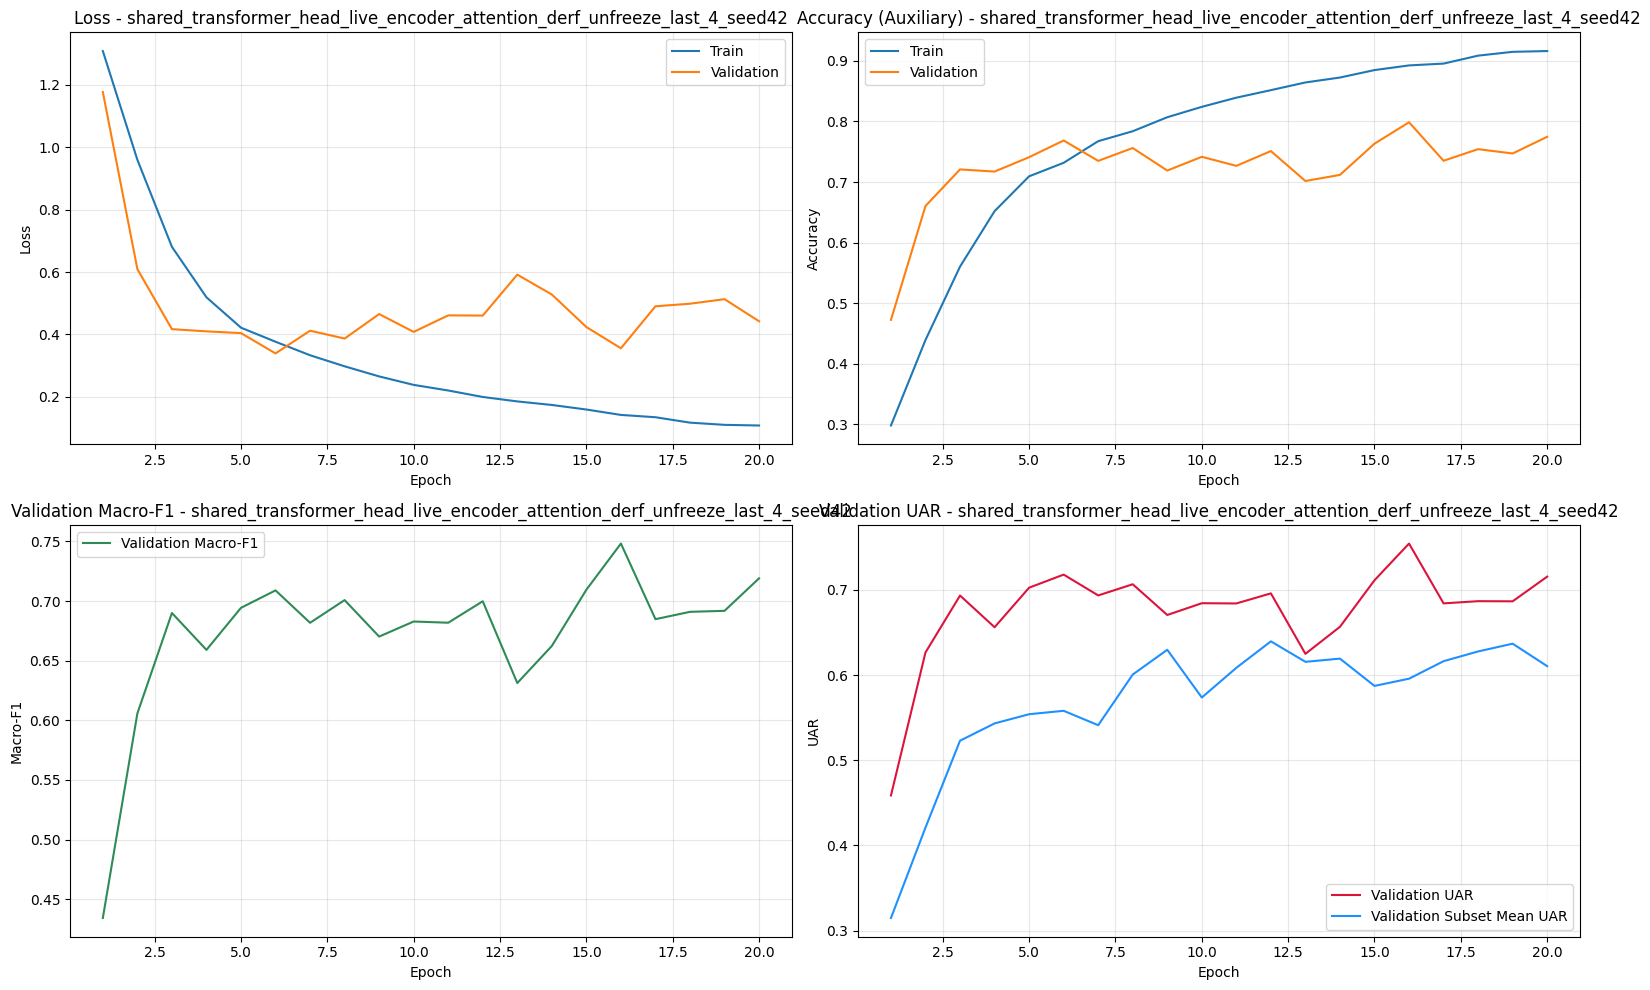

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax_loss = axes[0, 0]
ax_acc = axes[0, 1]
ax_f1 = axes[1, 0]
ax_uar = axes[1, 1]

epochs_range = range(1, len(history['val_loss']) + 1)

ax_loss.plot(epochs_range, history['train_loss'], label='Train')
ax_loss.plot(epochs_range, history['val_loss'], label='Validation')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.set_title(f'Loss - {experiment_name}')
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

ax_acc.plot(epochs_range, history['train_acc'], label='Train')
ax_acc.plot(epochs_range, history['val_acc'], label='Validation')
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Accuracy')
ax_acc.set_title(f'Accuracy (Auxiliary) - {experiment_name}')
ax_acc.legend()
ax_acc.grid(True, alpha=0.3)

ax_f1.plot(epochs_range, history['val_macro_f1'], label='Validation Macro-F1', color='#2E8B57')
ax_f1.set_xlabel('Epoch')
ax_f1.set_ylabel('Macro-F1')
ax_f1.set_title(f'Validation Macro-F1 - {experiment_name}')
ax_f1.legend()
ax_f1.grid(True, alpha=0.3)

ax_uar.plot(epochs_range, history['val_uar'], label='Validation UAR', color='#DC143C')
ax_uar.plot(epochs_range, history['val_subset_mean_uar'], label='Validation Subset Mean UAR', color='#1E90FF')
ax_uar.set_xlabel('Epoch')
ax_uar.set_ylabel('UAR')
ax_uar.set_title(f'Validation UAR - {experiment_name}')
ax_uar.legend()
ax_uar.grid(True, alpha=0.3)

plt.tight_layout()
experiment_curve_path = os.path.join(ckpt_dir, curve_filename)
plt.savefig(experiment_curve_path, dpi=150)
print(f'实验训练曲线已保存至: {experiment_curve_path}')
plt.show()


## 5. 测试集评估

              precision    recall  f1-score   support

       happy       0.58      0.60      0.59       947
       angry       0.72      0.81      0.76      1012
         sad       0.88      0.80      0.84       881
     neutral       0.87      0.89      0.88       933
        fear       0.53      0.73      0.61        90
    surprise       0.54      0.45      0.49       789

    accuracy                           0.72      4652
   macro avg       0.69      0.71      0.70      4652
weighted avg       0.72      0.72      0.72      4652

实验混淆矩阵已保存至: checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42_confusion_matrix.png


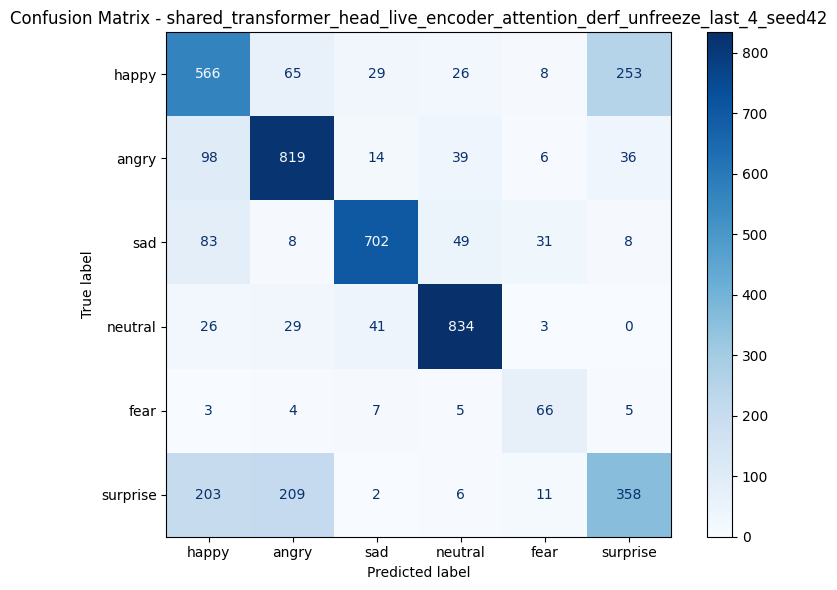

验证子集指标:
{'ravdess': {'samples': 120, 'loss': 0.4318772292385499, 'acc': 0.775, 'macro_f1': 0.7521936382864375, 'uar': 0.7430555555555557}, 'casia': {'samples': 300, 'loss': 0.9392689820130666, 'acc': 0.6266666666666667, 'macro_f1': 0.5991574912710039, 'uar': 0.6266666666666667}, 'esd': {'samples': 3499, 'loss': 0.3870273361929564, 'acc': 0.7805087167762218, 'macro_f1': 0.7844892740219596, 'uar': 0.7804680155323932}, 'emodb': {'samples': 55, 'loss': 0.8802407741546631, 'acc': 0.5636363636363636, 'macro_f1': 0.508904143189527, 'uar': 0.4930555555555556}, 'iemocap': {'samples': 779, 'loss': 0.5703939487141424, 'acc': 0.6765083440308087, 'macro_f1': 0.5420123702202692, 'uar': 0.5544346872908581}}
验证子集平均 UAR: 0.6395
测试子集指标:
{'ravdess': {'samples': 120, 'loss': 0.5869322592392564, 'acc': 0.7083333333333334, 'macro_f1': 0.6304895784210349, 'uar': 0.6597222222222222}, 'casia': {'samples': 300, 'loss': 0.7382928389310837, 'acc': 0.66, 'macro_f1': 0.6532024784620817, 'uar': 0.66}, 'esd': {'sampl

In [7]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)

model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for batch in test_loader:
        batch_inputs = move_batch_to_device(batch, device, training_mode, is_training=False)
        logits = forward_model(model, batch_inputs, training_mode)
        preds = logits.argmax(dim=1).cpu().numpy()
        labels = batch_inputs['labels'].cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels)

label_ids = list(range(len(EMOTION_LABELS)))
report_text = classification_report(
    all_labels_list,
    all_preds,
    labels=label_ids,
    target_names=EMOTION_LABELS,
    zero_division=0,
)
print(report_text)

cm = confusion_matrix(all_labels_list, all_preds, labels=label_ids)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - {experiment_name}')
plt.tight_layout()
experiment_cm_path = os.path.join(ckpt_dir, cm_filename)
plt.savefig(experiment_cm_path, dpi=150)
print(f'实验混淆矩阵已保存至: {experiment_cm_path}')
plt.show()

per_subset_val_metrics = evaluate_subset_loaders(
    model,
    val_loaders_by_subset,
    criterion,
    training_mode=training_mode,
    device=device,
)
per_subset_test_metrics = evaluate_subset_loaders(
    model,
    test_loaders_by_subset,
    criterion,
    training_mode=training_mode,
    device=device,
)
val_subset_mean_uar = compute_subset_mean_metric(per_subset_val_metrics, metric_key='uar', subset_order=main_subsets)
test_subset_mean_uar = compute_subset_mean_metric(per_subset_test_metrics, metric_key='uar', subset_order=main_subsets)
per_class_recall_values = recall_score(
    all_labels_list,
    all_preds,
    labels=label_ids,
    average=None,
    zero_division=0,
)
per_class_recall = {
    label: float(score)
    for label, score in zip(EMOTION_LABELS, per_class_recall_values)
}

print('验证子集指标:')
print(per_subset_val_metrics)
print(f'验证子集平均 UAR: {val_subset_mean_uar:.4f}')
print('测试子集指标:')
print(per_subset_test_metrics)
print(f'测试子集平均 UAR: {test_subset_mean_uar:.4f}')
print('逐类召回率:')
print(per_class_recall)

summary = {
    'protocol_version': int(protocol_version),
    'num_runs': 1,
    'experiment_name': experiment_name,
    'experiment_stem': experiment_stem,
    'variant': model.variant,
    'training_mode': training_mode,
    'seed': int(seed),
    'seed_sweep': list(seed_sweep),
    'included_subsets': list(main_subsets),
    'auxiliary_subsets': list(auxiliary_subsets),
    'split_meta': split_meta,
    'dataset_audit': dataset_audit['subset_audit'],
    'dataset_normalization_warnings': dataset_audit['normalization_warnings'],
    'auxiliary_eval_plan': auxiliary_eval_plan,
    'norm': model.shared_config.get('norm'),
    'pooling': model.shared_config.get('pooling'),
    'freeze_strategy': model.shared_config.get('freeze_strategy'),
    'criterion_name': criterion_name,
    'criterion_config': criterion_config,
    'class_weights': class_weights_dict,
    'virtual_train_class_counts': virtual_train_class_counts_dict,
    'subset_sampling_mode': subset_sampling_mode,
    'subset_sampling_with_replacement': bool(subset_sampling_with_replacement),
    'subset_class_balance_power': float(subset_class_balance_power),
    'subset_epoch_targets': train_sampling_meta['subset_targets'],
    'epochs_ran': int(len(history['val_loss'])),
    'best_metric': best_metric_label,
    'best_epoch': int(best_epoch),
    'selected_val_acc': float(best_selected_metrics['acc']),
    'selected_val_macro_f1': float(best_selected_metrics['macro_f1']),
    'selected_val_uar': float(best_selected_metrics['uar']),
    'selected_val_subset_mean_uar': float(best_selected_metrics['subset_mean_uar']),
    'selected_val_loss': float(best_val_loss_at_best),
    'best_val_loss': float(np.min(history['val_loss'])),
    'best_val_acc': float(np.max(history['val_acc'])),
    'best_val_macro_f1': float(np.max(history['val_macro_f1'])),
    'best_val_uar': float(np.max(history['val_uar'])),
    'best_val_subset_mean_uar': float(np.max(history['val_subset_mean_uar'])),
    'val_subset_mean_uar': float(val_subset_mean_uar),
    'test_acc': float(accuracy_score(all_labels_list, all_preds)),
    'macro_f1': float(f1_score(all_labels_list, all_preds, average='macro', zero_division=0)),
    'weighted_f1': float(f1_score(all_labels_list, all_preds, average='weighted', zero_division=0)),
    'uar': float(recall_score(all_labels_list, all_preds, average='macro', zero_division=0)),
    'test_subset_mean_uar': float(test_subset_mean_uar),
    'per_subset_val_metrics': per_subset_val_metrics,
    'per_subset_test_metrics': per_subset_test_metrics,
    'per_class_recall': per_class_recall,
    'aggregate_mean_std': None,
    'subset_epoch_caps': subset_epoch_caps,
    'raw_subset_train_samples': train_sampling_meta['raw_subset_counts'],
    'effective_subset_samples_per_epoch': train_sampling_meta['effective_subset_counts'],
    'oversampled_subset_samples_per_epoch': train_sampling_meta['oversampled_subset_counts'],
    'raw_train_samples': int(train_n),
    'effective_train_samples_per_epoch': int(train_sampling_meta['effective_train_samples_per_epoch']),
    'esd_epoch_cap': int(esd_epoch_cap),
    'raw_esd_train_samples': int(raw_esd_train_samples),
    'effective_esd_samples_per_epoch': int(train_sampling_meta['effective_subset_counts'].get('esd', 0)),
    'augmentation_config': augmentation_config,
    'checkpoint_filename': checkpoint_filename,
    'history_filename': history_filename,
    'summary_filename': summary_filename,
    'confusion_matrix_filename': cm_filename,
}
summary_path = os.path.join(ckpt_dir, summary_filename)
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('实验摘要:')
print(summary)
print(f'实验摘要已保存至: {summary_path}')


## 6. 跨架构对比

对比 `CNN+BiLSTM+Attention`（早期探索）与当前 `Whisper+Transformer Emotion Head` 主线配置的验证集表现；在默认设置下，这一节对应 `live_encoder + attention + derf + unfreeze_last_2` 主线协议。


当前共享模型对比实验 stem: shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4
当前共享模型对比实验 run: shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42
已加载 summary: emotion_summary.json
已加载: emotion_history.npz (78 epochs)
已加载 summary: shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42_summary.json
已加载: shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_seed42_history.npz (20 epochs)


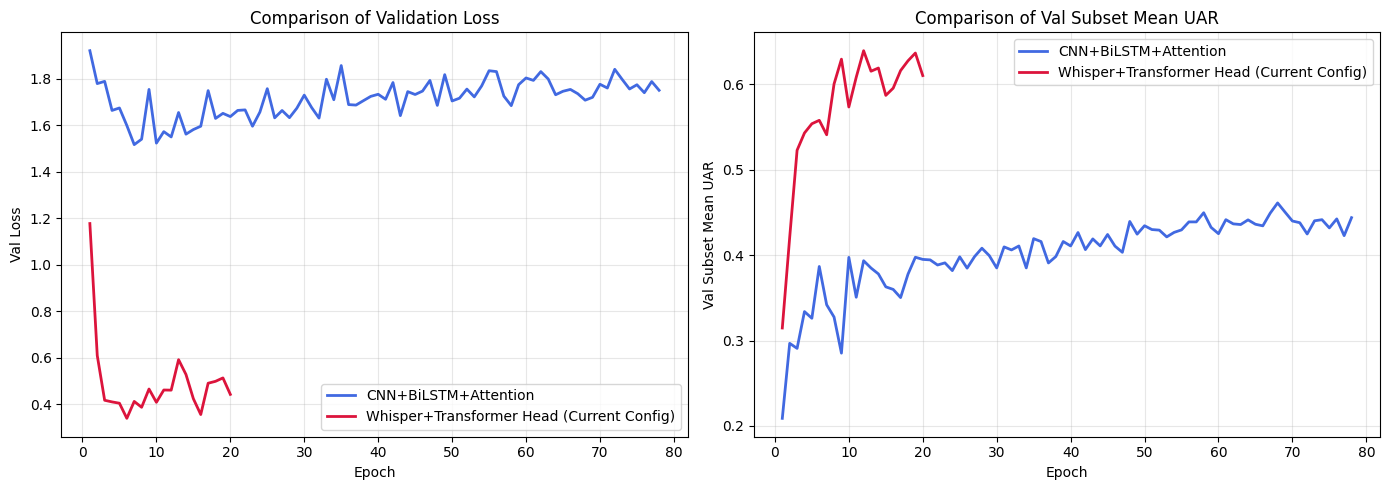


+-------------------------------------------+-----------------+---------------------------+--------------------+-------------------+------------+------------+---------------+------------+
| 模型                                      |   Best Val Loss |   Selected Val Subset UAR |   Selected Val UAR |   Test Subset UAR |   Test UAR |   Macro F1 |   Weighted F1 |   Test Acc |
+===========================================+=================+===========================+====================+===================+============+============+===============+============+
| CNN+BiLSTM+Attention                      |          1.5159 |                    46.12% |             55.75% |            42.40% |     56.90% |     0.5509 |        0.5775 |     57.85% |
+-------------------------------------------+-----------------+---------------------------+--------------------+-------------------+------------+------------+---------------+------------+
| Whisper+Transformer Head (Current Config) |          0.3394

In [8]:
from tabulate import tabulate

ckpt_dir = cfg['paths']['checkpoints']
shared_cfg = cfg['shared_model']
current_shared_experiment = build_experiment_name(
    shared_cfg['variant'],
    shared_cfg.get('training_mode', 'cached_pooled'),
    shared_cfg,
)
current_shared_run = resolve_experiment_run_name(current_shared_experiment, ckpt_dir, seed)
current_shared_label = 'Whisper+Transformer Head (Current Config)'
print(f'当前共享模型对比实验 stem: {current_shared_experiment}')
print(f'当前共享模型对比实验 run: {current_shared_run}')

MODEL_HISTORY = {
    'CNN+BiLSTM+Attention': 'emotion_history.npz',
    current_shared_label: f'{current_shared_run}_history.npz',
}
MODEL_SUMMARY = {
    'CNN+BiLSTM+Attention': 'emotion_summary.json',
    current_shared_label: f'{current_shared_run}_summary.json',
}
MODEL_COLORS = {
    'CNN+BiLSTM+Attention': '#4169E1',
    current_shared_label: '#DC143C',
}

def resolve_primary_curve_metric(histories):
    candidates = [
        ('val_subset_mean_uar', 'Val Subset Mean UAR'),
        ('val_uar', 'Val UAR'),
        ('val_acc', 'Val Accuracy (Auxiliary)'),
    ]
    for key, label in candidates:
        if all(key in history for history in histories):
            return key, label
    raise KeyError('历史中未找到可比较的验证指标。')

loaded = {}
for name, fname in MODEL_HISTORY.items():
    history_path = os.path.join(ckpt_dir, fname)
    if not os.path.isfile(history_path):
        print(f'未找到: {fname}，跳过 {name}')
        continue

    summary = None
    summary_path = os.path.join(ckpt_dir, MODEL_SUMMARY[name])
    if os.path.isfile(summary_path):
        with open(summary_path, 'r', encoding='utf-8') as f:
            summary = json.load(f)
        print(f'已加载 summary: {os.path.basename(summary_path)}')
    else:
        print(f'未找到 summary: {summary_path}，将仅基于 history 绘图。')

    loaded[name] = {
        'history': dict(np.load(history_path)),
        'summary': summary,
    }
    print(f'已加载: {fname} ({len(loaded[name]["history"]["val_loss"])} epochs)')

if len(loaded) == 2:
    histories = [data['history'] for data in loaded.values()]
    primary_key, primary_label = resolve_primary_curve_metric(histories)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for name, data in loaded.items():
        h = data['history']
        color = MODEL_COLORS[name]
        epochs_range = range(1, len(h['val_loss']) + 1)
        ax1.plot(epochs_range, h['val_loss'], label=name, color=color, linewidth=2)
        ax2.plot(epochs_range, h[primary_key], label=name, color=color, linewidth=2)

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Val Loss')
    ax1.set_title('Comparison of Validation Loss')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel(primary_label)
    ax2.set_title(f'Comparison of {primary_label}')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(ckpt_dir, 'model_comparison.png'), dpi=150)
    plt.show()
    print()

    summary_rows = []
    missing_summary = False
    for name, data in loaded.items():
        summary = data['summary']
        if summary is None:
            missing_summary = True
            continue
        summary_rows.append([
            name,
            summary.get('best_val_loss', float('nan')),
            summary.get('selected_val_subset_mean_uar', summary.get('best_val_subset_mean_uar', float('nan'))),
            summary.get('selected_val_uar', summary.get('best_val_uar', float('nan'))),
            summary.get('test_subset_mean_uar', float('nan')),
            summary.get('uar', float('nan')),
            summary.get('macro_f1', float('nan')),
            summary.get('weighted_f1', float('nan')),
            summary.get('test_acc', float('nan')),
        ])

    if summary_rows:
        print(tabulate(
            summary_rows,
            headers=['模型', 'Best Val Loss', 'Selected Val Subset UAR', 'Selected Val UAR', 'Test Subset UAR', 'Test UAR', 'Macro F1', 'Weighted F1', 'Test Acc'],
            floatfmt=['', '.4f', '.2%', '.2%', '.2%', '.2%', '.4f', '.4f', '.2%'],
            tablefmt='grid',
        ))
    if missing_summary:
        print('部分模型尚未生成 summary.json，表格中只展示已完成统一评估汇总的实验。')
else:
    print()
    print(f'只找到 {len(loaded)} 个模型的历史，需要两个才能对比。')
    print('请先运行 03_train_emotion.ipynb 与 04_train_shared.ipynb，生成统一 history/summary 后再比较。')


## 7. Derf 与 DyT 关键对比

在保持 `variant=transformer_head`、`training_mode=live_encoder`、`pooling=attention`、`freeze_strategy=unfreeze_last_2` 不变时，仅对比 `Derf` 与 `DyT` 两种主线任务头配置。该节对应论文中的关键设计对比，而不是大规模消融流程。


In [ ]:
from tabulate import tabulate

def load_experiment_group(experiment_stems, ckpt_dir, seed):
    loaded = {}
    for display_name, stem in experiment_stems.items():
        run_name = resolve_experiment_run_name(stem, ckpt_dir, seed)
        history_path = os.path.join(ckpt_dir, f'{run_name}_history.npz')
        summary_path = os.path.join(ckpt_dir, f'{run_name}_summary.json')
        aggregate_path = os.path.join(ckpt_dir, f'{stem}_aggregate.json')
        if not os.path.isfile(history_path):
            print(f'未找到 history: {history_path}，跳过 {display_name}')
            continue
        history = dict(np.load(history_path))
        summary = None
        summary_source = None
        if os.path.isfile(aggregate_path):
            with open(aggregate_path, 'r', encoding='utf-8') as f:
                summary = json.load(f)
            summary_source = aggregate_path
        elif os.path.isfile(summary_path):
            with open(summary_path, 'r', encoding='utf-8') as f:
                summary = json.load(f)
            summary_source = summary_path
        else:
            print(f'未找到 summary: {summary_path}，将只绘制曲线，不汇总测试指标。')
        loaded[display_name] = {
            'history': history,
            'summary': summary,
            'summary_source': summary_source,
            'run_name': run_name,
        }
        print(f'已加载: {display_name} <- {run_name}')
    return loaded

def resolve_primary_curve_metric(histories):
    candidates = [
        ('val_subset_mean_uar', 'Validation Subset Mean UAR'),
        ('val_uar', 'Validation UAR'),
        ('val_acc', 'Validation Accuracy (Auxiliary)'),
    ]
    for key, label in candidates:
        if all(key in history for history in histories):
            return key, label
    raise KeyError('历史中未找到可比较的验证指标。')

def plot_ablation_group(experiment_stems, ckpt_dir, figure_name, title_prefix):
    loaded = load_experiment_group(experiment_stems, ckpt_dir, seed)
    if len(loaded) < 2:
        print()
        print(f'只找到 {len(loaded)} 个实验结果，至少需要 2 个才能对比。')
        return

    primary_key, primary_label = resolve_primary_curve_metric([data['history'] for data in loaded.values()])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    color_cycle = ['#DC143C', '#1E90FF', '#228B22', '#FF8C00', '#8B008B']

    for idx, (name, data) in enumerate(loaded.items()):
        h = data['history']
        epochs_range = range(1, len(h['val_loss']) + 1)
        color = color_cycle[idx % len(color_cycle)]
        ax1.plot(epochs_range, h['val_loss'], label=name, color=color, linewidth=2)
        ax2.plot(epochs_range, h[primary_key], label=name, color=color, linewidth=2)

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Val Loss')
    ax1.set_title(f'{title_prefix} - Validation Loss')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel(primary_label)
    ax2.set_title(f'{title_prefix} - {primary_label}')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    output_path = os.path.join(ckpt_dir, figure_name)
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f'图像已保存至: {output_path}')

    summaries = {name: data['summary'] for name, data in loaded.items() if data['summary'] is not None}
    if summaries:
        headers = ['实验', 'Best Val Loss', 'Selected Val Subset UAR', 'Selected Val UAR', 'Test Subset UAR', 'Test UAR', 'Macro F1', 'Weighted F1', 'Test Acc']
        table_data = []
        for name, summary in summaries.items():
            table_data.append([
                name,
                summary.get('best_val_loss', float('nan')),
                summary.get('selected_val_subset_mean_uar', summary.get('best_val_subset_mean_uar', float('nan'))),
                summary.get('selected_val_uar', summary.get('best_val_uar', float('nan'))),
                summary.get('test_subset_mean_uar', float('nan')),
                summary.get('uar', float('nan')),
                summary.get('macro_f1', float('nan')),
                summary.get('weighted_f1', float('nan')),
                summary.get('test_acc', float('nan')),
            ])
        print(tabulate(
            table_data,
            headers=headers,
            floatfmt=['', '.4f', '.2%', '.2%', '.2%', '.2%', '.4f', '.4f', '.2%'],
            tablefmt='grid',
        ))
    else:
        print()
        print('当前只找到 history 文件，尚未找到 summary 文件，因此无法汇总统一测试指标。')

def build_transformer_experiment_stem(norm_name, freeze_name, training_mode, pooling='attention'):
    cfg_stub = {
        'pooling': pooling,
        'norm': norm_name,
        'freeze_strategy': freeze_name,
    }
    return build_experiment_name('transformer_head', training_mode, cfg_stub)

DERF_DYT_COMPARISON = {
    'Derf': build_transformer_experiment_stem('derf', 'unfreeze_last_2', 'live_encoder'),
    'DyT': build_transformer_experiment_stem('dyt', 'unfreeze_last_2', 'live_encoder'),
}

plot_ablation_group(
    DERF_DYT_COMPARISON,
    ckpt_dir=ckpt_dir,
    figure_name='shared_derf_dyt_comparison.png',
    title_prefix='Derf vs DyT (Mainline Protocol)',
)


## 8. 兼容性附录：冻结策略参考（可选）

这一节仅保留为工程兼容与后续研究扩展的参考入口，不属于当前论文默认实验流程。若需要复查 `freeze_all`、`unfreeze_last_2` 与 `unfreeze_last_4` 的差异，可将下方开关改为 `True` 后再执行。


In [ ]:
RUN_OPTIONAL_FREEZE_REFERENCE = False

FREEZE_REFERENCE = {
    'Derf + freeze_all': build_transformer_experiment_stem('derf', 'freeze_all', 'live_encoder'),
    'Derf + unfreeze_last_2': build_transformer_experiment_stem('derf', 'unfreeze_last_2', 'live_encoder'),
    'Derf + unfreeze_last_4': build_transformer_experiment_stem('derf', 'unfreeze_last_4', 'live_encoder'),
}

if RUN_OPTIONAL_FREEZE_REFERENCE:
    plot_ablation_group(
        FREEZE_REFERENCE,
        ckpt_dir=ckpt_dir,
        figure_name='shared_freeze_reference.png',
        title_prefix='Freeze Strategy Reference (Optional)',
    )
else:
    print('已跳过冻结策略参考图生成；当前默认流程只保留跨架构对比和 Derf/DyT 主线对比。')


## 9. 多 Seed 汇总

In [11]:
from tabulate import tabulate

AGGREGATE_METRIC_KEYS = (
    'best_val_loss',
    'best_val_acc',
    'selected_val_uar',
    'selected_val_subset_mean_uar',
    'test_acc',
    'test_subset_mean_uar',
    'macro_f1',
    'weighted_f1',
    'uar',
)

def compute_subset_mean_from_summary(summary, summary_key):
    if summary_key in summary:
        return float(summary[summary_key])

    if summary_key == 'selected_val_subset_mean_uar':
        metrics = summary.get('per_subset_val_metrics', {})
    elif summary_key == 'test_subset_mean_uar':
        metrics = summary.get('per_subset_test_metrics', {})
    else:
        return None

    values = [float(item.get('uar', float('nan'))) for item in metrics.values() if 'uar' in item]
    if not values:
        return None
    return float(np.mean(values))


def load_strict_summary(summary_path, strict_protocol_version):
    with open(summary_path, 'r', encoding='utf-8') as f:
        summary = json.load(f)
    if int(summary.get('protocol_version', -1)) != int(strict_protocol_version):
        return None
    return summary


def aggregate_experiment_summaries(experiment_stem, seeds, ckpt_dir):
    loaded = []
    for seed_value in seeds:
        run_name = build_run_name(experiment_stem, seed_value)
        summary_path = os.path.join(ckpt_dir, f'{run_name}_summary.json')
        if not os.path.isfile(summary_path):
            continue
        summary = load_strict_summary(summary_path, protocol_version)
        if summary is None:
            print(f'跳过 legacy summary: {summary_path}')
            continue
        loaded.append((int(seed_value), summary_path, summary))

    if not loaded:
        fallback_path = os.path.join(ckpt_dir, f'{experiment_stem}_summary.json')
        if os.path.isfile(fallback_path):
            summary = load_strict_summary(fallback_path, protocol_version)
            if summary is not None:
                loaded.append((None, fallback_path, summary))
            else:
                print(f'跳过 legacy summary: {fallback_path}')

    if not loaded:
        print(f'未找到任何严格协议 summary，可跳过聚合: {experiment_stem}')
        return None

    base_summary = loaded[0][2]
    aggregate_mean_std = {}
    aggregate_summary = {
        'protocol_version': int(base_summary.get('protocol_version', protocol_version)),
        'experiment_stem': experiment_stem,
        'included_subsets': base_summary.get('included_subsets', list(main_subsets)),
        'auxiliary_subsets': base_summary.get('auxiliary_subsets', list(auxiliary_subsets)),
        'num_runs': int(len(loaded)),
        'num_seeds': int(len(loaded)),
        'seeds': [seed_value for seed_value, _, _ in loaded if seed_value is not None],
        'source_summary_filenames': [os.path.basename(summary_path) for _, summary_path, _ in loaded],
        'aggregate_mean_std': aggregate_mean_std,
    }

    for key in AGGREGATE_METRIC_KEYS:
        values = []
        for _, _, summary in loaded:
            if key in summary:
                values.append(float(summary[key]))
                continue
            derived = compute_subset_mean_from_summary(summary, key)
            if derived is not None:
                values.append(float(derived))
        if not values:
            continue
        aggregate_mean_std[key] = {
            'mean': float(np.mean(values)),
            'std': float(np.std(values, ddof=0)),
        }
        aggregate_summary[key] = float(np.mean(values))

    aggregate_path = os.path.join(ckpt_dir, f'{experiment_stem}_aggregate.json')
    with open(aggregate_path, 'w', encoding='utf-8') as f:
        json.dump(aggregate_summary, f, ensure_ascii=False, indent=2)
    print(f'已写入聚合摘要: {aggregate_path}')
    return aggregate_summary


aggregate_targets = {
    'Current Config': current_shared_experiment,
    **NORM_ABLATION,
    **FREEZE_ABLATION,
}
aggregate_rows = []
for label, stem in aggregate_targets.items():
    aggregate_summary = aggregate_experiment_summaries(stem, seed_sweep, ckpt_dir)
    if aggregate_summary is None:
        continue
    metric = aggregate_summary.get('aggregate_mean_std', {})

    def fmt_percent(key):
        if key not in metric:
            return 'n/a'
        return f"{metric[key]['mean']:.2%} ± {metric[key]['std']:.2%}"

    def fmt_float(key):
        if key not in metric:
            return 'n/a'
        return f"{metric[key]['mean']:.4f} ± {metric[key]['std']:.4f}"

    aggregate_rows.append([
        label,
        int(aggregate_summary.get('num_runs', 0)),
        fmt_float('best_val_loss'),
        fmt_percent('best_val_acc'),
        fmt_percent('selected_val_subset_mean_uar'),
        fmt_percent('selected_val_uar'),
        fmt_percent('test_acc'),
        fmt_percent('test_subset_mean_uar'),
        fmt_float('macro_f1'),
        fmt_float('weighted_f1'),
        fmt_float('uar'),
    ])

if aggregate_rows:
    print(tabulate(
        aggregate_rows,
        headers=['实验', 'Runs', 'Best Val Loss', 'Best Val Acc', 'Selected Val Subset UAR', 'Selected Val UAR', 'Test Acc', 'Test Subset UAR', 'Macro F1', 'Weighted F1', 'UAR'],
        tablefmt='grid',
    ))
else:
    print('当前尚无可聚合的严格协议多 seed summary。')


已写入聚合摘要: checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_aggregate.json
已写入聚合摘要: checkpoints/shared_transformer_head_cached_sequence_attention_derf_freeze_all_aggregate.json
已写入聚合摘要: checkpoints/shared_transformer_head_cached_sequence_attention_dyt_freeze_all_aggregate.json
已写入聚合摘要: checkpoints/shared_transformer_head_cached_sequence_attention_layernorm_freeze_all_aggregate.json
已写入聚合摘要: checkpoints/shared_transformer_head_live_encoder_attention_derf_freeze_all_aggregate.json
已写入聚合摘要: checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_2_aggregate.json
已写入聚合摘要: checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_4_aggregate.json
+------------------------+--------+-----------------+----------------+---------------------------+--------------------+----------------+-------------------+-----------------+-----------------+-----------------+
| 实验                   |   Runs | Best Val Loss   | Best Val Acc   |